### Libraries

In [3]:
import json
import random
import os
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import train_test_split
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer

c:\Users\User\Documents\devanasokan_fyp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Setup

In [4]:
# Set random seeds for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed) # Set the seed for the current GPU
    torch.cuda.manual_seed_all(seed) # Set the seed for all GPUs (if you are using multi-GPU).
    
# Set deterministic behavior for CUDA operations
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Set environment variable for additional determinism
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':16:8'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
# Set up Hugging Face cache directory
cache_path = "../huggingface_cache"
cache_dir = Path(cache_path)
cache_dir.mkdir(parents=True, exist_ok=True)
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased", cache_dir=str(cache_dir))
print(f"Tokenizer vocab size: {len(tokenizer)}")

Tokenizer vocab size: 30522


In [6]:
# Set path for data
data_path = "../modeldata"

Choose between 2 different sets of data with different ratios

In [7]:
# Load the datasets (Ratio of 70:15:15 for train, validation, and test sets)
train_df = pd.read_csv(f"{data_path}/train70.csv")
val_df = pd.read_csv(f"{data_path}/val15.csv")
test_df = pd.read_csv(f"{data_path}/test15.csv")

ratio = "70:15:15"

In [8]:
# Load the datasets (Ratio of 80:10:10 for train, validation, and test sets)
train_df = pd.read_csv(f"{data_path}/train80.csv")
val_df = pd.read_csv(f"{data_path}/val10.csv")
test_df = pd.read_csv(f"{data_path}/test10.csv")

ratio = "80:10:10"

In [9]:
# Ratio used
print(f"Data split ratio: {ratio}")

Data split ratio: 80:10:10


Once a set has been chosen, continue with next steps

In [10]:
print(train_df['label'].value_counts(normalize=True))
print(val_df['label'].value_counts(normalize=True))
print(test_df['label'].value_counts(normalize=True))

label
1    0.5
0    0.5
Name: proportion, dtype: float64
label
1    0.5
0    0.5
Name: proportion, dtype: float64
label
0    0.5
1    0.5
Name: proportion, dtype: float64


In [11]:
print("train:", train_df.shape, train_df["label"].value_counts().sort_index().to_dict())
print("val:", val_df.shape, val_df["label"].value_counts().sort_index().to_dict())
print("test:", test_df.shape, test_df["label"].value_counts().sort_index().to_dict())

train: (18302, 2) {0: 9151, 1: 9151}
val: (2288, 2) {0: 1144, 1: 1144}
test: (2288, 2) {0: 1144, 1: 1144}


In [12]:
MAX_LEN = 180


def tokenize(text: str) -> list[str]:
    return tokenizer.tokenize(text)


counter = Counter()
for text in train_df["verse"]:
    counter.update(tokenize(text))

vocab = tokenizer.get_vocab()

print(f"Vocabulary size: {len(vocab)}")
print("Most common tokens:", counter.most_common(10))

Token indices sequence length is longer than the specified maximum sequence length for this model (657 > 512). Running this sequence through the model will result in indexing errors


Vocabulary size: 30522
Most common tokens: [(',', 216322), ('i', 54906), ('you', 40629), ('the', 31056), ('to', 24273), ('it', 20227), ('a', 19852), ('me', 18337), ('and', 17799), ('not', 15771)]


In [13]:
def numericalize(text: str) -> tuple[torch.Tensor, torch.Tensor]:
    token_ids = tokenizer.encode(
        text,
        add_special_tokens=False,
        truncation=True,
        max_length=MAX_LEN,
    )
    if not token_ids:
        token_ids = [tokenizer.unk_token_id]
    length = len(token_ids)
    if len(token_ids) < MAX_LEN:
        token_ids += [tokenizer.pad_token_id] * (MAX_LEN - len(token_ids))
    return torch.tensor(token_ids, dtype=torch.long), torch.tensor(length, dtype=torch.long)

sample_ids, sample_length = numericalize(train_df.iloc[0]["verse"] )
print("sample length:", sample_length.item())
print("sample ids:", sample_ids[:20].tolist())

sample length: 61
sample ids: [2026, 1010, 2026, 1010, 2092, 1010, 2009, 2003, 25085, 2066, 2057, 2024, 2035, 2183, 2000, 3280, 1010, 2035, 2183, 2000]


In [14]:
class LyricsDataset(Dataset):
    def __init__(self, frame: pd.DataFrame):
        self.texts = frame["verse"].tolist()
        self.labels = frame["label"].astype(np.float32).tolist()

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, index: int):
        input_ids, length = numericalize(self.texts[index])
        label = torch.tensor(self.labels[index], dtype=torch.float32)
        return input_ids, length, label

### Hyperparameter Tuning with Optuna

We'll search for the best hyperparameters using Optuna, which efficiently explores different combinations and focuses on promising regions. We'll tune:
- Learning rate (1e-4 to 1e-3)
- Embedding dimension (64, 128, 256)
- Hidden dimension (128, 256, 512)
- Number of layers (1, 2, 3)
- Dropout rate (0.1 to 0.5)
- Batch size (16, 32, 64)

In [15]:
# Define the RNN model
class RNNClassifier(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int = 128,
        hidden_dim: int = 128,
        num_layers: int = 2,
        bidirectional: bool = True,
        dropout: float = 0.3,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=tokenizer.pad_token_id)
        self.rnn = nn.RNN(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity="tanh", # For RNN
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        output_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(output_dim, 1)

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        embedded = self.embedding(input_ids)
        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, hidden = self.rnn(packed)
        if self.rnn.bidirectional:
            hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            hidden = hidden[-1]
        logits = self.fc(self.dropout(hidden))
        return logits.squeeze(1)

In [16]:
# Run one epoch of training or evaluation
def run_epoch(model, loader: DataLoader, criterion, optimizer=None, training: bool = True):
    model.train() if training else model.eval()

    total_loss = 0.0
    all_predictions = []
    all_probs = []
    all_targets = []

    for input_ids, lengths, labels in loader:
        input_ids = input_ids.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device)

        with torch.set_grad_enabled(training):
            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        # Get probability scores
        probs = torch.sigmoid(logits)
        all_probs.extend(probs.detach().cpu().tolist())

        predictions = (probs >= 0.5).long()
        all_predictions.extend(predictions.detach().cpu().tolist())
        all_targets.extend(labels.detach().cpu().long().tolist())
        total_loss += loss.item() * input_ids.size(0)

    average_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_targets, all_predictions)
    return average_loss, accuracy, all_targets, all_probs, all_predictions

In [17]:
# Create a seeded generator for the DataLoader
g = torch.Generator()
g.manual_seed(42)

In [18]:
import optuna
from optuna.pruners import MedianPruner

def objective(trial: optuna.Trial):
    # Set the random seed for reproducibility
    g.manual_seed(42)
    
    # Suggest hyperparameters
    learning_rate = trial.suggest_categorical("learning_rate", [1e-4, 5e-4, 1e-3])
    embedding_dim = trial.suggest_categorical("embedding_dim", [64, 128, 256])
    hidden_dim = trial.suggest_categorical("hidden_dim", [128, 256, 512])
    num_layers = trial.suggest_int("num_layers", 1, 3)
    dropout = trial.suggest_categorical("dropout", [0.1, 0.3, 0.5])
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    # Create data loaders with the suggested batch size
    # train_loader = DataLoader(LyricsDataset(train_df), batch_size=batch_size, shuffle=True)
    train_loader = DataLoader(
        LyricsDataset(train_df), 
        batch_size=batch_size, 
        shuffle=True,
        generator=g,           
        num_workers=0          # for reproducibility
    )
    val_loader = DataLoader(LyricsDataset(val_df), batch_size=batch_size, shuffle=False, num_workers=0)

    # Initialize model with suggested hyperparameters
    model = RNNClassifier(
        vocab_size=len(tokenizer),
        embedding_dim=embedding_dim,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout,
    ).to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # Train for a few epochs with Early Stopping
    num_epochs = 10
    best_val_acc = 0
    patience = 3
    patience_counter = 0

    for epoch in range(num_epochs):
        train_loss, train_acc, _, _, _ = run_epoch(model, train_loader, criterion, optimizer, training=True)
        val_loss, val_acc, _, _, _ = run_epoch(model, val_loader, criterion, training=False)

        print(f"  Trial {trial.number}, Epoch {epoch + 1}/{num_epochs}: val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

        # Early Stopping Logic (Patience = 3)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0  # Reset patience counter when accuracy improves
        else:
            patience_counter += 1  # Increment patience counter when accuracy doesn't improve

        # Prune trial if validation accuracy is not improving (MedianPruner)
        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        # Early stop if patience is exceeded
        if patience_counter >= patience:
            print(f"  Early stopping triggered! No improvement for {patience} epochs.")
            break

    return best_val_acc

In [19]:
# For reproducibility, set a fixed seed for the TPE sampler
sampler = optuna.samplers.TPESampler(seed=42)

In [ ]:
# Create a study and run the hyperparameter search
study = optuna.create_study(
    study_name="rnn_tuning",
    direction="maximize",  # Maximize validation accuracy
    sampler=sampler, 
    pruner=MedianPruner(),
)

study.optimize(objective, n_trials=20, show_progress_bar=True)

[I 2026-08-15 12:26:14,244] A new study created in memory with name: no-name-df084da8-d8ff-435c-95b7-a56460022673
  0%|          | 0/20 [00:00<?, ?it/s]

  Trial 0, Epoch 1/10: val_loss=0.6684, val_acc=0.5970
  Trial 0, Epoch 2/10: val_loss=0.6761, val_acc=0.5927
  Trial 0, Epoch 3/10: val_loss=0.6695, val_acc=0.5848


Best trial: 0. Best value: 0.597028:   5%|▌         | 1/20 [08:46<2:46:36, 526.13s/it]

  Trial 0, Epoch 4/10: val_loss=0.6810, val_acc=0.5747
  Early stopping triggered! No improvement for 3 epochs.
[I 2026-08-15 12:35:00,370] Trial 0 finished with value: 0.597027972027972 and parameters: {'learning_rate': 0.0005, 'embedding_dim': 64, 'hidden_dim': 256, 'num_layers': 3, 'dropout': 0.3, 'batch_size': 16}. Best is trial 0 with value: 0.597027972027972.
  Trial 1, Epoch 1/10: val_loss=0.6908, val_acc=0.5354
  Trial 1, Epoch 2/10: val_loss=0.6784, val_acc=0.5752
  Trial 1, Epoch 3/10: val_loss=0.6743, val_acc=0.5739
  Trial 1, Epoch 4/10: val_loss=0.6889, val_acc=0.5743


Best trial: 0. Best value: 0.597028:  10%|█         | 2/20 [18:34<2:48:53, 562.98s/it]

...

  Trial 17, Epoch 10/10: val_loss=0.6089, val_acc=0.6849
  Early stopping triggered! No improvement for 3 epochs.
[I 2026-08-15 14:02:58,568] Trial 17 finished with value: 0.7495629370629371 and parameters: {'learning_rate': 0.0005, 'embedding_dim': 256, 'hidden_dim': 128, 'num_layers': 1, 'dropout': 0.5, 'batch_size': 32}. Best is trial 8 with value: 0.7539335664335665.
  Trial 18, Epoch 1/10: val_loss=0.6305, val_acc=0.6521
  Trial 18, Epoch 2/10: val_loss=0.5872, val_acc=0.6901
  Trial 18, Epoch 3/10: val_loss=0.5887, val_acc=0.6976
  Trial 18, Epoch 4/10: val_loss=0.5659, val_acc=0.7107
  Trial 18, Epoch 5/10: val_loss=0.6621, val_acc=0.6761
  Trial 18, Epoch 6/10: val_loss=0.5694, val_acc=0.7015
  Trial 18, Epoch 7/10: val_loss=0.5776, val_acc=0.7133
  Trial 18, Epoch 8/10: val_loss=0.5968, val_acc=0.6958
  Trial 18, Epoch 9/10: val_loss=0.6475, val_acc=0.6534


Best trial: 8. Best value: 0.753934:  95%|█████████▌| 19/20 [1:38:59<02:54, 174.59s/it]

  Trial 18, Epoch 10/10: val_loss=0.6186, val_acc=0.6849
[I 2026-08-15 14:05:14,114] Trial 18 pruned. 
  Trial 19, Epoch 1/10: val_loss=0.6390, val_acc=0.6364
  Trial 19, Epoch 2/10: val_loss=0.6141, val_acc=0.6683
  Trial 19, Epoch 3/10: val_loss=0.6003, val_acc=0.6844
  Trial 19, Epoch 4/10: val_loss=0.6150, val_acc=0.6705
  Trial 19, Epoch 5/10: val_loss=0.5823, val_acc=0.6962
  Trial 19, Epoch 6/10: val_loss=0.5624, val_acc=0.7268
  Trial 19, Epoch 7/10: val_loss=0.5843, val_acc=0.7150
  Trial 19, Epoch 8/10: val_loss=0.5851, val_acc=0.7185


Best trial: 8. Best value: 0.753934: 100%|██████████| 20/20 [1:44:07<00:00, 312.38s/it]

  Trial 19, Epoch 9/10: val_loss=0.5846, val_acc=0.7233
  Early stopping triggered! No improvement for 3 epochs.
[I 2026-08-15 14:10:21,883] Trial 19 finished with value: 0.7268356643356644 and parameters: {'learning_rate': 0.0005, 'embedding_dim': 128, 'hidden_dim': 128, 'num_layers': 1, 'dropout': 0.1, 'batch_size': 16}. Best is trial 8 with value: 0.7539335664335665.


In [21]:
# Print best trial results
best_trial = study.best_trial

print(f"Best validation accuracy: {best_trial.value:.4f}")
print("Best hyperparameters:")
for key, value in best_trial.params.items():
    print(f"  {key}: {value}")

Best validation accuracy: 0.7539
Best hyperparameters:
  learning_rate: 0.0005
  embedding_dim: 256
  hidden_dim: 128
  num_layers: 3
  dropout: 0.3
  batch_size: 32


In [22]:
# Reset seeds before final model creation
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
random.seed(42)
np.random.seed(42)

# Create fresh generator
g_final = torch.Generator() # Use g_final in DataLoaders instead of g
g_final.manual_seed(42)

### Final Training with Best Hyperparameters

Train the final model using the best hyperparameters found by Optuna on the full train set, and evaluate on the test set.

In [23]:
# Extract best hyperparameters
best_params = best_trial.params
best_learning_rate = best_params["learning_rate"]
best_embedding_dim = best_params["embedding_dim"]
best_hidden_dim = best_params["hidden_dim"]
best_num_layers = best_params["num_layers"]
best_dropout = best_params["dropout"]
best_batch_size = best_params["batch_size"]

# Create data loaders with best batch size
train_loader = DataLoader(LyricsDataset(train_df), batch_size=best_batch_size, shuffle=True, generator=g_final, num_workers=0)
val_loader = DataLoader(LyricsDataset(val_df), batch_size=best_batch_size, shuffle=False, generator=g_final, num_workers=0)
test_loader = DataLoader(LyricsDataset(test_df), batch_size=best_batch_size, shuffle=False, generator=g_final, num_workers=0)

# Initialize final model with best hyperparameters
model = RNNClassifier(
    vocab_size=len(tokenizer),
    embedding_dim=best_embedding_dim,
    hidden_dim=best_hidden_dim,
    num_layers=best_num_layers,
    dropout=best_dropout,
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=best_learning_rate)

print("Final model architecture:")
print(model)

Final model architecture:
RNNClassifier(
  (embedding): Embedding(30522, 256, padding_idx=0)
  (rnn): RNN(256, 128, num_layers=3, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)


In [24]:
# Train the final model with best hyperparameters

num_epochs = 10
best_val_acc = 0
best_model_path = Path("rnn_lyrics_classifier.pt")
history = []

# Add patience variables for early stopping
patience = 3
patience_counter = 0

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc, train_targets, train_probs, train_predictions = run_epoch(model, train_loader, criterion, optimizer, training=True)
    val_loss, val_acc, val_targets, val_probs, val_predictions = run_epoch(model, val_loader, criterion, training=False)
    
    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        }
    )

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    # Check if validation accuracy improved
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0  # Reset patience counter when accuracy improves
        torch.save(model.state_dict(), best_model_path)
    else:
        patience_counter += 1  # Increment patience counter when accuracy doesn't improve
    
    # Early stopping logic - break if patience is exceeded
    if patience_counter >= patience:
        print(f"\nEarly stopping triggered! No improvement for {patience} consecutive epochs.")
        print(f"Best validation accuracy: {best_val_acc:.4f}")
        break

history_df = pd.DataFrame(history)
history_df

Epoch 01 | train_loss=0.6685 train_acc=0.5890 | val_loss=0.6197 val_acc=0.6705
Epoch 02 | train_loss=0.6042 train_acc=0.6799 | val_loss=0.6386 val_acc=0.6591
Epoch 03 | train_loss=0.6163 train_acc=0.6577 | val_loss=0.6074 val_acc=0.6678
Epoch 04 | train_loss=0.5430 train_acc=0.7300 | val_loss=0.5837 val_acc=0.6984
Epoch 05 | train_loss=0.4818 train_acc=0.7776 | val_loss=0.5444 val_acc=0.7242
Epoch 06 | train_loss=0.4877 train_acc=0.7722 | val_loss=0.5833 val_acc=0.7094
Epoch 07 | train_loss=0.4685 train_acc=0.7838 | val_loss=0.5853 val_acc=0.6980
Epoch 08 | train_loss=0.4429 train_acc=0.7964 | val_loss=0.5644 val_acc=0.7264
Epoch 09 | train_loss=0.4012 train_acc=0.8255 | val_loss=0.5956 val_acc=0.7386
Epoch 10 | train_loss=0.4078 train_acc=0.8193 | val_loss=0.5564 val_acc=0.7443


,epoch,train_loss,train_acc,val_loss,val_acc
0,1,0.668468,0.589007,0.619661,0.670455
1,2,0.604216,0.679871,0.638570,0.659091
2,3,0.616333,0.657742,0.607441,0.667832
3,4,0.543026,0.730030,0.583728,0.698427
4,5,0.481840,0.777620,0.544419,0.724213
5,6,0.487654,0.772211,0.583316,0.709353
6,7,0.468549,0.783794,0.585307,0.697990
7,8,0.442897,0.796361,0.564405,0.726399
8,9,0.401221,0.825538,0.595635,0.738636
9,10,0.407841,0.819309,0.556355,0.744318


### Model Evaluation

In [25]:
# Load best checkpoint and evaluate on test
model.load_state_dict(torch.load(best_model_path, map_location=device))
test_loss, test_acc, test_targets, test_probs, test_predictions = run_epoch(model, test_loader, criterion, training=False)

#### Classification Report

In [26]:
report = classification_report(
    test_targets,
    test_predictions,
    output_dict=True
)

accuracy = report["accuracy"]
precision = report["1"]["precision"]
recall = report["1"]["recall"]
f1 = report["1"]["f1-score"]

print(f"RNN CLASSIFICATION REPORT (TUNING - {ratio}):")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

RNN CLASSIFICATION REPORT (TUNING - 80:10:10):
Accuracy: 0.7486888111888111
Precision: 0.748471615720524
Recall: 0.7491258741258742
F1-score: 0.7487986020096112


#### ROC-AUC Curve

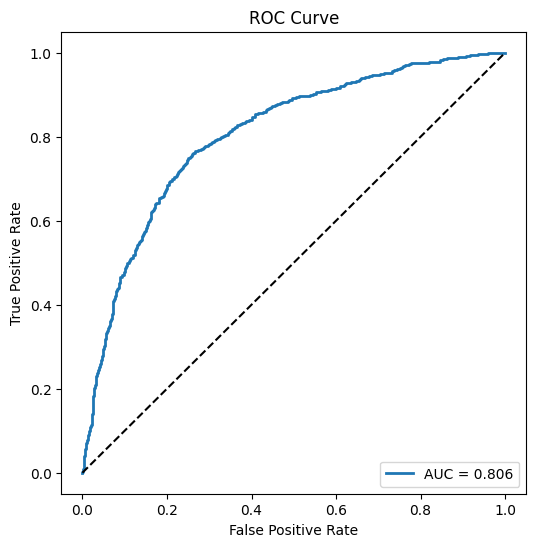

In [27]:
fpr, tpr, thresholds = roc_curve(test_targets, test_probs)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}",
    linewidth=2
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.show()

#### Precision-Recall Curve

PR-AUC: 0.7836670521005893


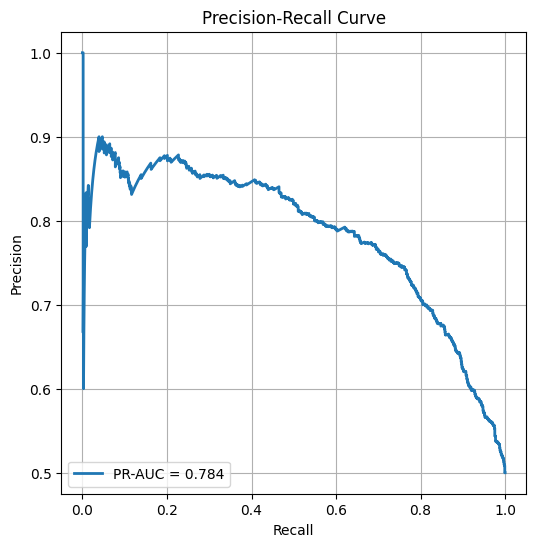

In [28]:
precision, recall, thresholds = precision_recall_curve(
    test_targets,
    test_probs
)

pr_auc = auc(recall, precision)

print("PR-AUC:", pr_auc)

plt.figure(figsize=(6,6))

plt.plot(
    recall,
    precision,
    label=f"PR-AUC = {pr_auc:.3f}",
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend(loc="lower left")
plt.grid()

plt.show()

#### Confusion Matrix

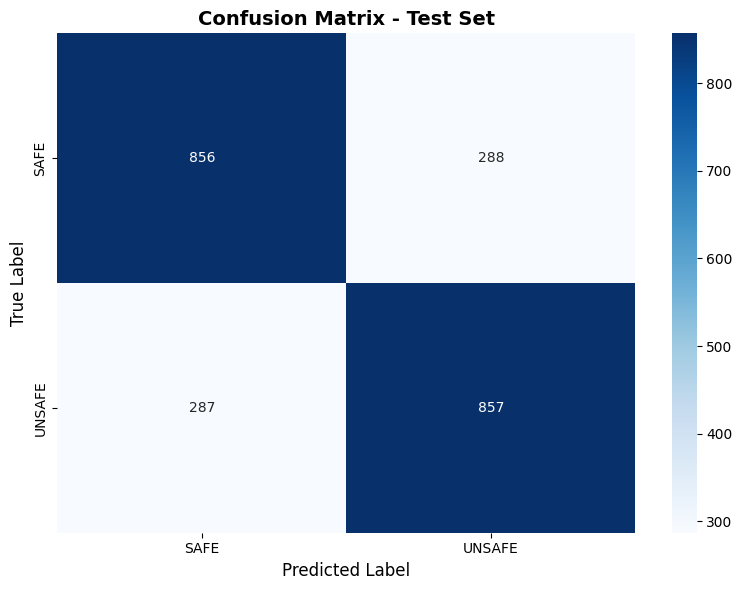

In [29]:
# Confusion matrix
cm = pd.crosstab(pd.Series(test_targets, name="Actual"), pd.Series(test_predictions, name="Predicted"))

# Create the plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True,  # Show numbers in cells
    fmt='d',     # Format as integers
    cmap='Blues',  # Color palette
    cbar=True,   # Show color bar
    xticklabels=['SAFE', 'UNSAFE'],
    yticklabels=['SAFE', 'UNSAFE']
)
 
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()